# sample7 - 転移学習（Keras Applications）

Keras Applications に内蔵された事前学習済みモデルを使って転移学習を行います。  
PyTorch の sample7 と同じ CIFAR-10 を題材に、Keras での書き方を比較します。

| ステップ | 内容 |
|----------|------|
| 1 | 事前学習済みモデルの読み込み |
| 2 | 最終層の差し替え |
| 3 | データ準備 |
| 4 | 学習・評価 |

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # GPU を無効化して CPU で実行
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

I0000 00:00:1771827240.997253  169102 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1771827241.873504  169102 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.22.0-dev20260222
GPU: []


## 1. 転移学習の考え方

```
事前学習済みモデル（ImageNet 1000クラスで学習済み）
  ├── 特徴抽出層（凍結） ← そのまま再利用
  └── 最終分類層        ← 自分のクラス数に差し替えて学習
```

Keras では `trainable = False` で層を凍結します。

## 2. 事前学習済みモデルの読み込みと最終層の差し替え

In [2]:
# MobileNetV2 を使用（ResNet より軽量で速い）
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,      # 最終分類層を除く
    weights='imagenet'      # ImageNet の事前学習済み重み
)

# 特徴抽出層を凍結
base_model.trainable = False

# 学習可能パラメータの確認
trainable = sum([tf.size(w).numpy() for w in base_model.trainable_weights])
total     = sum([tf.size(w).numpy() for w in base_model.weights])
print(f"学習可能パラメータ: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
学習可能パラメータ: 0 / 2,257,984 (0.0%)


In [3]:
# Functional API で最終層を差し替え
inputs  = tf.keras.Input(shape=(96, 96, 3))
x       = base_model(inputs, training=False)  # training=False で BN を凍結
x       = tf.keras.layers.GlobalAveragePooling2D()(x)
x       = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)  # CIFAR-10 は10クラス

model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 3. データ準備（CIFAR-10）

初回実行時にデータが自動ダウンロードされます（約170MB）。

In [4]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# 学習時間短縮のため 1000件に絞る
X_train, y_train = X_train[:1000], y_train[:1000]
X_test,  y_test  = X_test[:500],   y_test[:500]

# 96x96 にリサイズ・正規化
def preprocess(images):
    images = tf.image.resize(images, (96, 96))
    return tf.keras.applications.mobilenet_v2.preprocess_input(images)

X_train = preprocess(X_train.astype('float32'))
X_test  = preprocess(X_test.astype('float32'))

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']
print("学習データ:", X_train.shape, "テストデータ:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 23s 0us/step


/home/user/HOME/sample/sample_python/403_TensorFlowKeras/env/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


学習データ: (1000, 96, 96, 3) テストデータ: (500, 96, 96, 3)


## 4. 学習・評価

In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.2812 - loss: 2.2803 - val_accuracy: 0.4800 - val_loss: 1.4311
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6425 - loss: 1.0772 - val_accuracy: 0.6900 - val_loss: 0.9990
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7588 - loss: 0.7191 - val_accuracy: 0.7250 - val_loss: 0.8529
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8225 - loss: 0.5320 - val_accuracy: 0.7300 - val_loss: 0.8062
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8462 - loss: 0.4530 - val_accuracy: 0.7400 - val_loss: 0.7784
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.8788 - loss: 0.3723 - val_accuracy: 0.7650 - val_loss: 0.7436
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9175 - loss: 0.2932 - val_accuracy: 0.7600 - val_loss: 0.7377
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9262 - loss: 0.2653 - val_accuracy: 0.7650 - v

テスト Accuracy: 0.7940


/tmp/ipykernel_169102/1877065367.py:17: UserWarning: Glyph 36578 (\N{CJK UNIFIED IDEOGRAPH-8EE2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_169102/1877065367.py:17: UserWarning: Glyph 31227 (\N{CJK UNIFIED IDEOGRAPH-79FB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_169102/1877065367.py:17: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_169102/1877065367.py:17: UserWarning: Glyph 32722 (\N{CJK UNIFIED IDEOGRAPH-7FD2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_169102/1877065367.py:17: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_169102/1877065367.py:17: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/user/HOME/sample/sample_python/403_TensorFlowKeras/env/lib/python3.12/site-

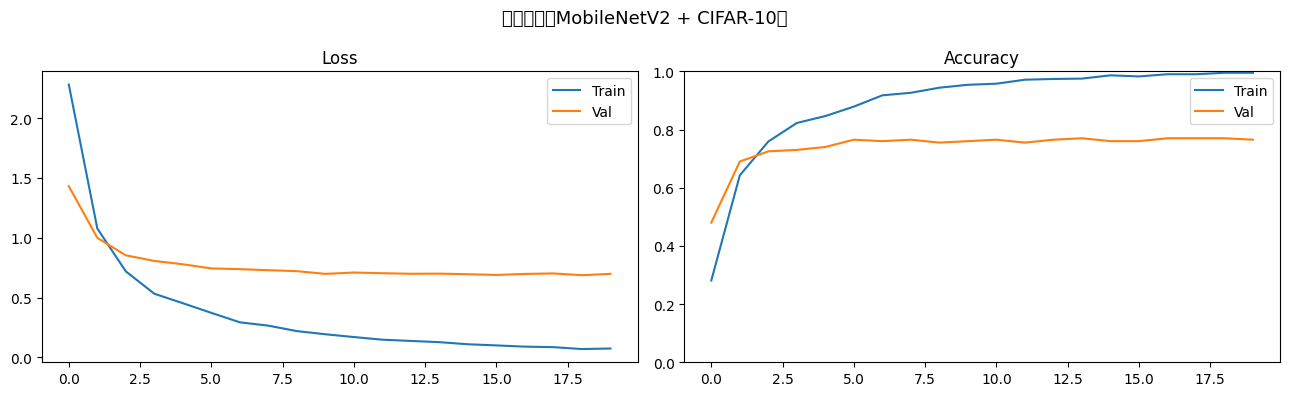

In [6]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"テスト Accuracy: {acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.suptitle('転移学習（MobileNetV2 + CIFAR-10）', fontsize=13)
plt.tight_layout()
plt.show()